# Actividad 13 — GC2: SARIMAX + LSTM Híbrido

**Fase 3 — Entrenamiento de Modelos**  
**Proyecto:** Predicción de Demanda Agroindustrial — Limón Peruano

## Arquitectura Híbrida

```
y_train + X_exog  ──► SARIMAX ──► residuos_train
                                        │
                               LSTM (sin Attention)
                                        │
y_pred = SARIMAX_forecast + LSTM_correction
```

- **SARIMAX**: captura el componente lineal, estacional y el efecto de variables exógenas (clima NASA + INDECI).
- **LSTM**: aprende patrones no lineales en los residuos que SARIMAX no capturó.
- **Sin NLP / sin Attention**: diferencia respecto a GC3 y modelos multimodales.

## Variables exógenas (8)
- **NASA POWER (6):** `T2M`, `PRECTOTCORR`, `QV2M`, `RH2M`, `ALLSKY_SFC_SW_DWN`, `WS2M`
- **INDECI (2):** `num_emergencias`, `hectareas_cultivo_perdidas`

## Protocolo
- Agregación: **media provincial** (`.mean()`) — mismo criterio que GC1
- Split **cronológico estricto 80/20**
- SARIMAX y LSTM ajustan **exclusivamente sobre el conjunto de entrenamiento**
- Datos en **escala z-score** (normalizados en Fase 2)

## Outputs
```
resultados/gc2/
  ├── gc2_sarimax_model.pkl
  ├── gc2_lstm_model.keras
  ├── gc2_scalers.pkl
  ├── gc2_metricas.json
  ├── gc2_predicciones.csv
  ├── gc2_lstm_training_curve.png
  ├── gc2_residuos_sarimax.png
  └── gc2_prediccion_vs_real.png
```

## 1. Imports y configuración

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import joblib
from pathlib import Path

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.facecolor'] = 'white'

print(f'TensorFlow : {tf.__version__}')
print('Imports OK.')

TensorFlow : 2.21.0
Imports OK.


In [2]:
# ── Rutas ──────────────────────────────────────────────────────────
PROYECTO_ROOT  = Path(r'C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-')
DATASET_PATH   = PROYECTO_ROOT / 'data' / 'processed' / 'master_dataset_fase2_multivariado.csv'
RESULTADOS_DIR = PROYECTO_ROOT / 'resultados' / 'gc2'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

# ── Split ──────────────────────────────────────────────────────────
SPLIT_RATIO  = 0.80

# ── Variables exógenas ────────────────────────────────────────────
EXOG_COLS = [
    'T2M',                        # temperatura promedio NASA
    'PRECTOTCORR',                 # precipitacion NASA
    'QV2M',                        # humedad especifica NASA
    'RH2M',                        # humedad relativa NASA
    'ALLSKY_SFC_SW_DWN',           # radiacion solar NASA
    'WS2M',                        # velocidad viento NASA
    'num_emergencias',              # INDECI: numero de eventos
    'hectareas_cultivo_perdidas',   # INDECI: impacto directo en cultivos
]

# ── SARIMAX ───────────────────────────────────────────────────────
SARIMAX_ORDER          = (1, 0, 0)
SARIMAX_SEASONAL_ORDER = (2, 1, 0, 12)

# ── LSTM ──────────────────────────────────────────────────────────
SEQ_LEN      = 6      # ventana de observaciones previas
LSTM_UNITS   = 32     # liviano: dataset pequeño (44 meses train)
DROPOUT      = 0.30
EPOCHS       = 300
BATCH_SIZE   = 4
PATIENCE     = 25
RANDOM_STATE = 42

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('Configuracion cargada.')
print(f'  Variables exogenas ({len(EXOG_COLS)}): {EXOG_COLS}')
print(f'  SARIMAX: {SARIMAX_ORDER} x {SARIMAX_SEASONAL_ORDER}')
print(f'  LSTM   : seq_len={SEQ_LEN}, units={LSTM_UNITS}, dropout={DROPOUT}')

Configuracion cargada.
  Variables exogenas (8): ['T2M', 'PRECTOTCORR', 'QV2M', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'num_emergencias', 'hectareas_cultivo_perdidas']
  SARIMAX: (1, 0, 0) x (2, 1, 0, 12)
  LSTM   : seq_len=6, units=32, dropout=0.3


## 2. Carga y agregación del dataset

In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['fecha_evento'])
print(f'Dataset crudo: {df.shape[0]:,} filas x {df.shape[1]} columnas')

# Media provincial mensual para target + variables exógenas
cols_agg = ['produccion_t'] + EXOG_COLS
nacional = (
    df.groupby('fecha_evento')[cols_agg]
    .mean()
    .sort_index()
)
nacional.index = pd.DatetimeIndex(nacional.index, freq='MS')

print(f'Serie nacional (media provincial): {nacional.shape}')
print(f'Periodo: {nacional.index.min().date()} -> {nacional.index.max().date()}')
nacional.describe().round(4)

Dataset crudo: 5,880 filas x 24 columnas
Serie nacional (media provincial): (56, 9)
Periodo: 2021-01-01 -> 2025-08-01


,produccion_t,T2M,PRECTOTCORR,QV2M,RH2M,ALLSKY_SFC_SW_DWN,WS2M,num_emergencias,hectareas_cultivo_perdidas
count,56.0000,56.0000,56.0000,56.0000,56.0000,56.0000,56.0000,56.0000,56.0000
mean,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000
std,0.0705,0.1266,0.3852,0.2853,0.4661,0.4285,0.1127,0.3931,0.0976
min,-0.1338,-0.3117,-0.5036,-0.4939,-0.8483,-0.9126,-0.2057,-0.2498,-0.0139
25%,-0.0510,-0.0728,-0.3494,-0.2394,-0.4149,-0.2872,-0.0926,-0.2498,-0.0139
50%,-0.0072,0.0001,-0.1015,0.0266,0.0837,-0.1109,-0.0056,-0.2498,-0.0139
75%,0.0424,0.0586,0.2511,0.2306,0.4093,0.3602,0.0941,0.0780,-0.0136
max,0.1438,0.2675,0.9946,0.5188,0.7511,1.1530,0.2051,1.3984,0.7167


## 3. Split cronológico 80/20

  Total : 56 meses
  Train : 44 meses  [2021-01-01 -> 2024-08-01]
  Test  : 12 meses  [2024-09-01  -> 2025-08-01]
  Corte : 2024-09-01


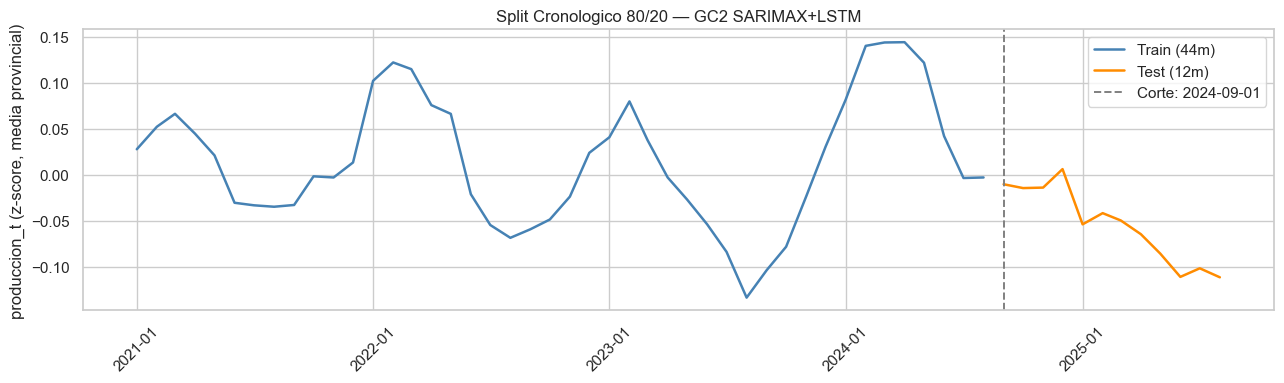

In [4]:
n_total = len(nacional)
n_train = int(n_total * SPLIT_RATIO)
n_test  = n_total - n_train

train_df   = nacional.iloc[:n_train].copy()
test_df    = nacional.iloc[n_train:].copy()
split_date = nacional.index[n_train]

y_train = train_df['produccion_t']
y_test  = test_df['produccion_t']
X_train = train_df[EXOG_COLS]
X_test  = test_df[EXOG_COLS]

print('=' * 55)
print(f'  Total : {n_total} meses')
print(f'  Train : {n_train} meses  [{y_train.index.min().date()} -> {y_train.index.max().date()}]')
print(f'  Test  : {n_test} meses  [{y_test.index.min().date()}  -> {y_test.index.max().date()}]')
print(f'  Corte : {split_date.date()}')
print('=' * 55)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_train.index, y_train.values, label=f'Train ({n_train}m)', color='steelblue', lw=1.8)
ax.plot(y_test.index,  y_test.values,  label=f'Test ({n_test}m)',  color='darkorange', lw=1.8)
ax.axvline(split_date, color='gray', ls='--', lw=1.4, label=f'Corte: {split_date.date()}')
ax.set_title('Split Cronologico 80/20 — GC2 SARIMAX+LSTM', fontsize=12)
ax.set_ylabel('produccion_t (z-score, media provincial)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc2_split_cronologico.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Normalización de variables exógenas

`StandardScaler` ajustado **solo sobre `X_train`** para evitar data leakage.

In [5]:
scaler_X = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler_X.fit_transform(X_train),
    columns=EXOG_COLS, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler_X.transform(X_test),
    columns=EXOG_COLS, index=X_test.index
)
print(f'X_train escalado: {X_train_sc.shape}')
print(f'X_test  escalado: {X_test_sc.shape}')
print('\nScaler ajustado solo sobre train (no leakage).')

X_train escalado: (44, 8)
X_test  escalado: (12, 8)

Scaler ajustado solo sobre train (no leakage).


## 5. Entrenamiento SARIMAX

Mismo orden que GC1 SARIMA + variables exógenas. El modelo captura:
- **AR(1)**: autocorrelación de corto plazo  
- **SAR(2), SMA(1), D=1, m=12**: patrón estacional anual  
- **Exog (8 vars)**: efecto lineal del clima NASA + eventos INDECI

In [6]:
print(f'Entrenando SARIMAX{SARIMAX_ORDER}x{SARIMAX_SEASONAL_ORDER} con {len(EXOG_COLS)} variables exogenas...')

sarimax_mdl = SARIMAX(
    y_train,
    exog=X_train_sc,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_res = sarimax_mdl.fit(disp=False, maxiter=500)

print('\nEntrenamiento SARIMAX completado.')
print(f'  AIC  : {sarimax_res.aic:.4f}')
print(f'  BIC  : {sarimax_res.bic:.4f}')
print(f'  HQIC : {sarimax_res.hqic:.4f}')

Entrenando SARIMAX(1, 0, 0)x(2, 1, 0, 12) con 8 variables exogenas...



Entrenamiento SARIMAX completado.
  AIC  : -101.8873
  BIC  : -102.5364
  HQIC : -109.9098


C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
print(sarimax_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       produccion_t   No. Observations:                   44
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                  62.944
Date:                            Mon, 25 May 2026   AIC                           -101.887
Time:                                    16:01:44   BIC                           -102.536
Sample:                                01-01-2021   HQIC                          -109.910
                                     - 08-01-2024                                         
Covariance Type:                              opg                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
T2M                            0.0347      0.000    146.986      0.000       0.034

## 6. Residuos SARIMAX — input del LSTM

El LSTM aprende a corregir lo que SARIMAX no capturó (no linealidades, interacciones).

Residuos SARIMAX (train): 44 obs
  Media : 0.002753
  Std   : 0.152408
  Min   : -0.232265
  Max   : 0.600682


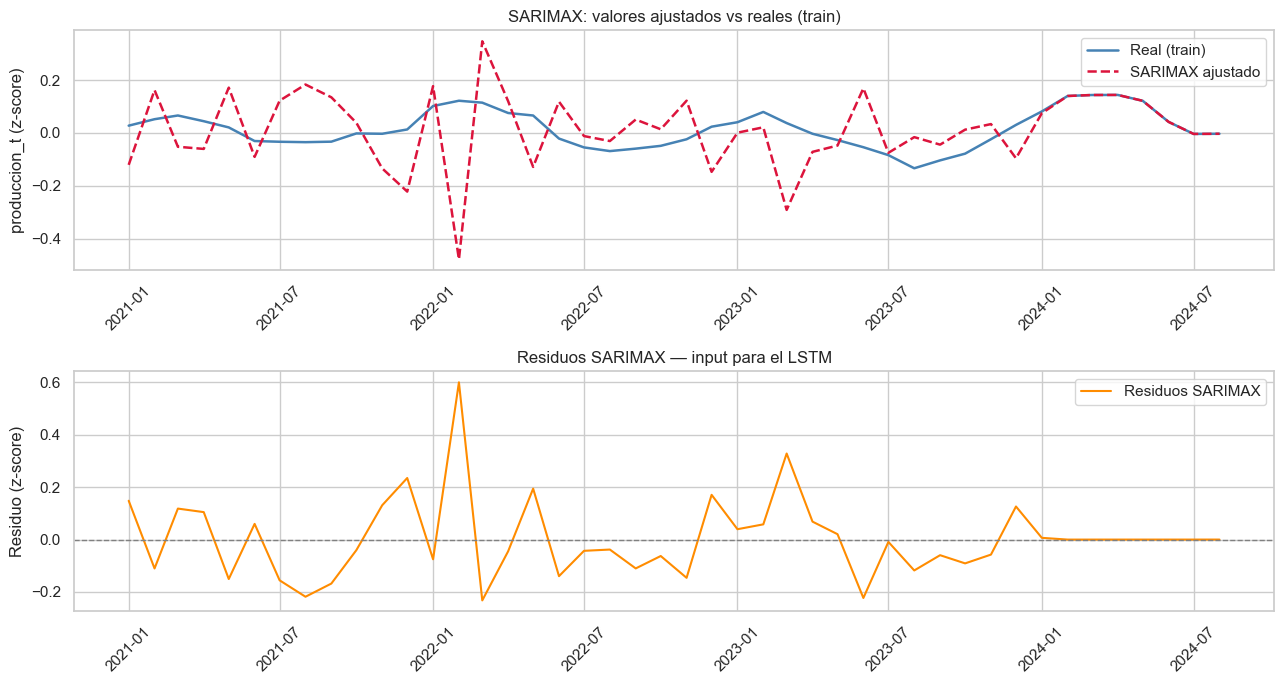

Grafico guardado -> gc2_residuos_sarimax.png


In [8]:
y_train_fitted   = sarimax_res.fittedvalues
residuals_series = y_train - y_train_fitted
residuals_arr    = residuals_series.values

print(f'Residuos SARIMAX (train): {len(residuals_arr)} obs')
print(f'  Media : {residuals_arr.mean():.6f}')
print(f'  Std   : {residuals_arr.std():.6f}')
print(f'  Min   : {residuals_arr.min():.6f}')
print(f'  Max   : {residuals_arr.max():.6f}')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(y_train.index, y_train.values,       label='Real (train)',      color='steelblue',  lw=1.8)
axes[0].plot(y_train.index, y_train_fitted.values, label='SARIMAX ajustado', color='crimson',    lw=1.8, ls='--')
axes[0].set_title('SARIMAX: valores ajustados vs reales (train)', fontsize=12)
axes[0].set_ylabel('produccion_t (z-score)'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(y_train.index, residuals_arr, color='darkorange', lw=1.5, label='Residuos SARIMAX')
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_title('Residuos SARIMAX — input para el LSTM', fontsize=12)
axes[1].set_ylabel('Residuo (z-score)'); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc2_residuos_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado -> gc2_residuos_sarimax.png')

## 7. Construcción de secuencias para el LSTM

Cada secuencia `X[i]` tiene forma `(seq_len, 1 + n_exog)`:  
el canal de residuos + las 8 variables exógenas. El target `y[i]` es el residuo en `t+1`.

In [9]:
# Normalizar residuos para el LSTM
scaler_r = StandardScaler()
res_scaled = scaler_r.fit_transform(residuals_arr.reshape(-1, 1)).flatten()


def make_sequences(residuals: np.ndarray,
                   exog_arr:  np.ndarray,
                   seq_len:   int):
    """
    Builds (X_seq, y_seq) without leakage.
    X_seq[i] : (seq_len, 1 + n_exog)  — residuals + exog window
    y_seq[i] : scalar                  — residual at t+seq_len
    """
    X_list, y_list = [], []
    for i in range(len(residuals) - seq_len):
        res_win  = residuals[i : i + seq_len].reshape(-1, 1)
        exog_win = exog_arr[i : i + seq_len]
        X_list.append(np.hstack([res_win, exog_win]))
        y_list.append(residuals[i + seq_len])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


exog_train_arr = X_train_sc.values
X_seq, y_seq   = make_sequences(res_scaled, exog_train_arr, SEQ_LEN)

n_features = X_seq.shape[2]  # 1 residual + len(EXOG_COLS)
print(f'Secuencias LSTM  : {X_seq.shape}  (batch, seq_len={SEQ_LEN}, features={n_features})')
print(f'Targets          : {y_seq.shape}')
print(f'  n_exog         : {len(EXOG_COLS)}')
print(f'  Secuencias disp.: {len(X_seq)} de {n_train} posibles')

Secuencias LSTM  : (38, 6, 9)  (batch, seq_len=6, features=9)
Targets          : (38,)
  n_exog         : 8
  Secuencias disp.: 38 de 44 posibles


## 8. Entrenamiento LSTM (sin Attention)

Arquitectura conservadora para dataset pequeño:
```
Input (seq_len=6, features=9)
  └─► LSTM(32) ──► Dropout(0.30)
        └─► Dense(16, relu) ──► Dense(1)
```

In [10]:
def build_lstm(seq_len: int, n_features: int, units: int, dropout: float) -> keras.Model:
    inp = keras.Input(shape=(seq_len, n_features), name='input')
    x   = layers.LSTM(units, return_sequences=False, name='lstm')(inp)
    x   = layers.Dropout(dropout, name='dropout')(x)
    x   = layers.Dense(units // 2, activation='relu', name='dense_hidden')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inp, out, name='GC2_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


lstm_model = build_lstm(SEQ_LEN, n_features, LSTM_UNITS, DROPOUT)
lstm_model.summary()

cb_es  = callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=12,
    min_lr=1e-6, verbose=0
)

print(f'\nEntrenando LSTM sobre {len(X_seq)} secuencias...')
history = lstm_model.fit(
    X_seq, y_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[cb_es, cb_rlr],
    verbose=0
)
n_epochs_run = len(history.history['loss'])
print(f'Entrenamiento detenido en epoca {n_epochs_run}  (best val_loss = {min(history.history["val_loss"]):.6f})')

Model: "GC2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 6, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando LSTM sobre 38 secuencias...


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 1.


Entrenamiento detenido en epoca 26  (best val_loss = 0.072740)


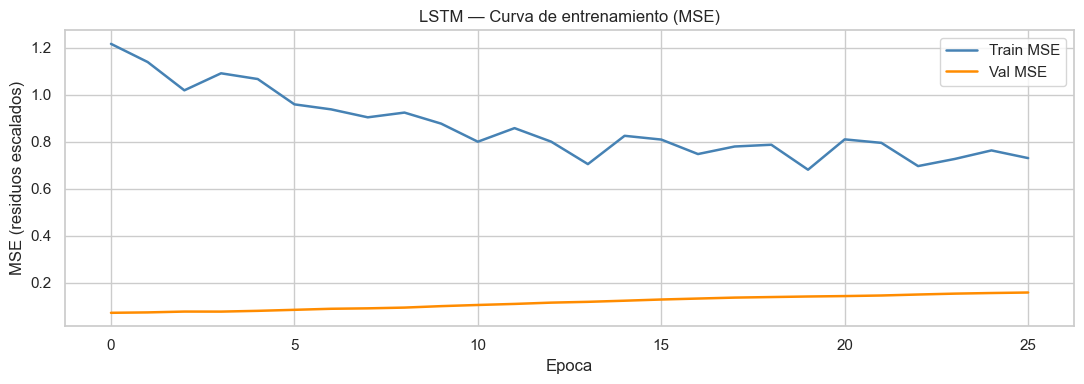

Curva guardada -> gc2_lstm_training_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(history.history['loss'],     label='Train MSE', color='steelblue', lw=1.8)
ax.plot(history.history['val_loss'], label='Val MSE',   color='darkorange', lw=1.8)
ax.set_title('LSTM — Curva de entrenamiento (MSE)', fontsize=12)
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE (residuos escalados)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc2_lstm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curva guardada -> gc2_lstm_training_curve.png')

## 9. Predicciones híbridas sobre el conjunto de prueba

**Sin data leakage:**
1. SARIMAX predice usando `X_test` (variables exógenas observadas en el período de prueba).
2. LSTM predice correcciones de residuos usando los últimos `SEQ_LEN` residuos de train como semilla,
   avanzando recursivamente con las variables exógenas de test.
3. `y_pred = SARIMAX_forecast + LSTM_correction` (ambos en escala original z-score).

In [12]:
# ── Paso 1: SARIMAX forecast ───────────────────────────────────────
print('Paso 1: Generando forecast SARIMAX para el periodo de prueba...')
sarimax_fc    = sarimax_res.forecast(steps=n_test, exog=X_test_sc)
sarimax_pred  = sarimax_fc.values
print(f'  SARIMAX forecast: {sarimax_pred.shape}  min={sarimax_pred.min():.4f}  max={sarimax_pred.max():.4f}')

# ── Paso 2: LSTM residual correction (recursivo) ──────────────────
print('Paso 2: Generando correcciones LSTM de residuos (multi-step recursivo)...')

exog_test_arr = X_test_sc.values          # (n_test, n_exog)
# Semilla: ultimos SEQ_LEN residuos de train (en escala normalizada)
current_res_window = res_scaled[-SEQ_LEN:].copy()   # (SEQ_LEN,)

lstm_corr_scaled = []
for step in range(n_test):
    # Construir exog_window: combina exog recientes de test
    start_idx = max(0, step - SEQ_LEN + 1)
    end_idx   = step + 1
    avail_exog = exog_test_arr[start_idx:end_idx]   # puede ser < SEQ_LEN al inicio

    if len(avail_exog) < SEQ_LEN:
        # Completar con la ultima fila de train (conservador)
        pad = np.tile(exog_train_arr[-1], (SEQ_LEN - len(avail_exog), 1))
        exog_window = np.vstack([pad, avail_exog])  # (SEQ_LEN, n_exog)
    else:
        exog_window = avail_exog                     # (SEQ_LEN, n_exog)

    res_window = current_res_window.reshape(-1, 1)   # (SEQ_LEN, 1)
    x_input    = np.hstack([res_window, exog_window])[np.newaxis].astype(np.float32)  # (1, SEQ_LEN, features)
    pred_r     = float(lstm_model.predict(x_input, verbose=0)[0, 0])
    lstm_corr_scaled.append(pred_r)

    # Avanzar ventana de residuos
    current_res_window = np.roll(current_res_window, -1)
    current_res_window[-1] = pred_r

lstm_corr_scaled = np.array(lstm_corr_scaled)
lstm_corr = scaler_r.inverse_transform(lstm_corr_scaled.reshape(-1, 1)).flatten()

# ── Paso 3: Prediccion hibrida final ──────────────────────────────
y_pred_hybrid = sarimax_pred + lstm_corr

print(f'Paso 3: Prediccion hibrida generada.')
print(f'  SARIMAX contrib. media : {sarimax_pred.mean():.6f}')
print(f'  LSTM corr.  media      : {lstm_corr.mean():.6f}')
print(f'  Hibrido     media      : {y_pred_hybrid.mean():.6f}')

comparacion = pd.DataFrame({
    'fecha'          : y_test.index,
    'real'           : y_test.values,
    'sarimax'        : sarimax_pred,
    'lstm_correccion': lstm_corr,
    'hibrido'        : y_pred_hybrid,
    'error_abs'      : np.abs(y_test.values - y_pred_hybrid),
})
print('\nPrimeras 6 predicciones:')
print(comparacion.head(6).round(4).to_string(index=False))

Paso 1: Generando forecast SARIMAX para el periodo de prueba...
  SARIMAX forecast: (12,)  min=-0.7822  max=0.0475
Paso 2: Generando correcciones LSTM de residuos (multi-step recursivo)...


Paso 3: Prediccion hibrida generada.
  SARIMAX contrib. media : -0.212673
  LSTM corr.  media      : -0.026216
  Hibrido     media      : -0.238889

Primeras 6 predicciones:
     fecha    real  sarimax  lstm_correccion  hibrido  error_abs
2024-09-01 -0.0106  -0.0722           0.0151  -0.0571     0.0465
2024-10-01 -0.0147  -0.1125           0.0092  -0.1033     0.0886
2024-11-01 -0.0142  -0.4026           0.0072  -0.3954     0.3812
2024-12-01  0.0059   0.0475           0.0038   0.0512     0.0454
2025-01-01 -0.0542  -0.0594          -0.0028  -0.0622     0.0080
2025-02-01 -0.0420  -0.5182          -0.0194  -0.5377     0.4957


## 10. Métricas de evaluación

In [13]:
def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8) -> float:
    mask = np.abs(y_true) > epsilon
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


y_true = y_test.values

# Hibrido
mae_h  = mean_absolute_error(y_true, y_pred_hybrid)
rmse_h = float(np.sqrt(mean_squared_error(y_true, y_pred_hybrid)))
mape_h = safe_mape(y_true, y_pred_hybrid)
r2_h   = r2_score(y_true, y_pred_hybrid)

# Solo SARIMAX (ablacion)
mae_s  = mean_absolute_error(y_true, sarimax_pred)
rmse_s = float(np.sqrt(mean_squared_error(y_true, sarimax_pred)))
r2_s   = r2_score(y_true, sarimax_pred)

metricas = {
    'modelo'           : 'GC2_SARIMAX_LSTM',
    'sarimax_order'    : str(SARIMAX_ORDER),
    'sarimax_seasonal' : str(SARIMAX_SEASONAL_ORDER),
    'exog_vars'        : EXOG_COLS,
    'lstm_units'       : LSTM_UNITS,
    'seq_len'          : SEQ_LEN,
    'epochs_run'       : n_epochs_run,
    'n_train'          : int(n_train),
    'n_test'           : int(n_test),
    'split_date'       : str(split_date.date()),
    'MAE'              : round(mae_h,  6),
    'RMSE'             : round(rmse_h, 6),
    'MAPE_pct'         : round(mape_h, 4) if not np.isnan(mape_h) else None,
    'R2'               : round(r2_h,   6),
    'ablation_SARIMAX_only_MAE'  : round(mae_s,  6),
    'ablation_SARIMAX_only_RMSE' : round(rmse_s, 6),
    'ablation_SARIMAX_only_R2'   : round(r2_s,   6),
    'nota'             : 'metricas en z-score (media provincial Fase 2)'
}

print('=' * 60)
print('  METRICAS GC2 — SARIMAX+LSTM  (conjunto de prueba)')
print('=' * 60)
print(f'  [Hibrido]      MAE={mae_h:.6f}  RMSE={rmse_h:.6f}  R2={r2_h:.4f}')
print(f'  [Solo SARIMAX] MAE={mae_s:.6f}  RMSE={rmse_s:.6f}  R2={r2_s:.4f}')
if not np.isnan(mape_h):
    print(f'  MAPE (hibrido): {mape_h:.4f}%')
print('=' * 60)
print('  NOTA: metricas en escala z-score (media provincial).')

  METRICAS GC2 — SARIMAX+LSTM  (conjunto de prueba)
  [Hibrido]      MAE=0.196891  RMSE=0.292599  R2=-53.6344
  [Solo SARIMAX] MAE=0.179828  RMSE=0.272143  R2=-46.2622
  MAPE (hibrido): 586.2436%
  NOTA: metricas en escala z-score (media provincial).


## 11. Persistencia del modelo y resultados

In [14]:
# SARIMAX
joblib.dump(sarimax_res, RESULTADOS_DIR / 'gc2_sarimax_model.pkl')

# LSTM
lstm_model.save(RESULTADOS_DIR / 'gc2_lstm_model.keras')

# Scalers
joblib.dump({'scaler_X': scaler_X, 'scaler_r': scaler_r},
            RESULTADOS_DIR / 'gc2_scalers.pkl')

# Metricas
with open(RESULTADOS_DIR / 'gc2_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

# Predicciones
comparacion.to_csv(RESULTADOS_DIR / 'gc2_predicciones.csv', index=False)

print('Archivos guardados:')
for p in sorted(RESULTADOS_DIR.iterdir()):
    print(f'  {p.name:<42} {p.stat().st_size/1024:>7.1f} KB')

Archivos guardados:
  gc2_lstm_model.keras                         102.4 KB
  gc2_lstm_training_curve.png                   56.0 KB
  gc2_metricas.json                              0.7 KB
  gc2_predicciones.csv                           1.4 KB
  gc2_residuos_sarimax.png                     168.1 KB
  gc2_sarimax_model.pkl                      12242.3 KB
  gc2_scalers.pkl                                1.4 KB
  gc2_split_cronologico.png                     88.7 KB


## 12. Gráfico: Predicción vs Real

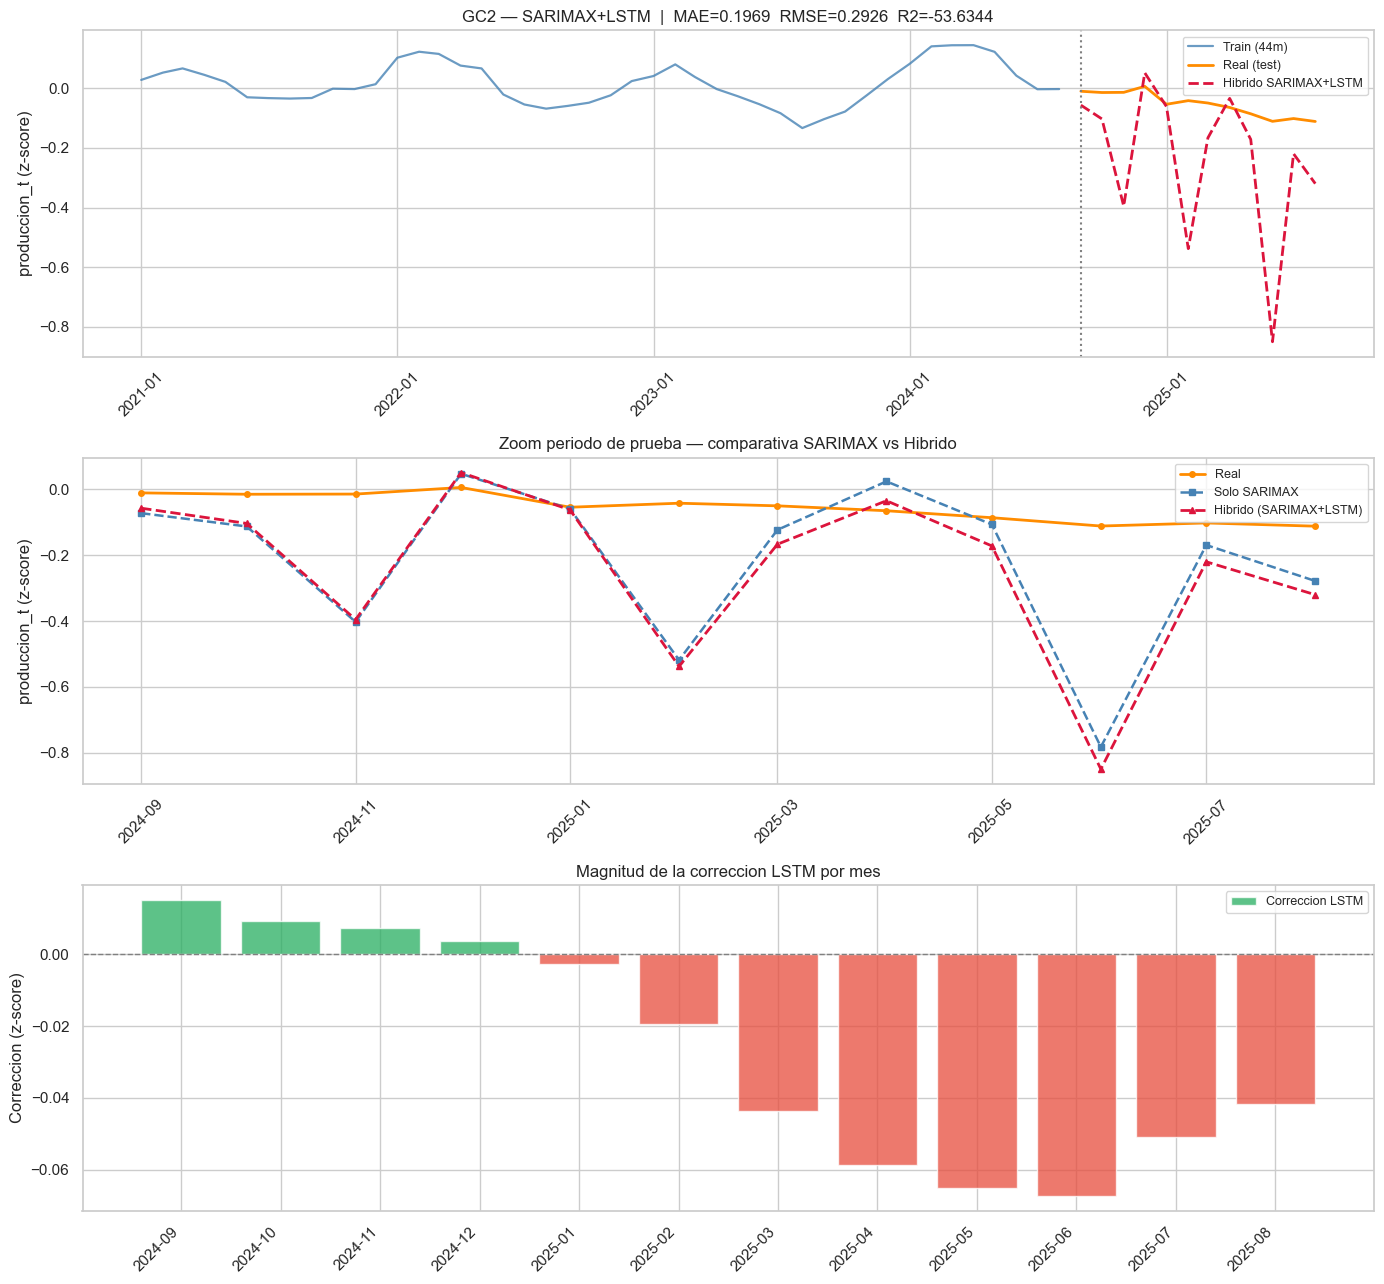

Grafico guardado -> gc2_prediccion_vs_real.png


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# ── Panel 1: serie completa ───────────────────────────────────────
axes[0].plot(y_train.index, y_train.values,
             label=f'Train ({n_train}m)', color='steelblue', lw=1.6, alpha=0.8)
axes[0].plot(y_test.index, y_test.values,
             label='Real (test)', color='darkorange', lw=2)
axes[0].plot(y_test.index, y_pred_hybrid,
             label='Hibrido SARIMAX+LSTM', color='crimson', lw=2, ls='--')
axes[0].axvline(split_date, color='gray', ls=':', lw=1.5)
axes[0].set_title(
    f'GC2 — SARIMAX+LSTM  |  MAE={mae_h:.4f}  RMSE={rmse_h:.4f}  R2={r2_h:.4f}',
    fontsize=12)
axes[0].set_ylabel('produccion_t (z-score)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# ── Panel 2: zoom test con desglose SARIMAX / LSTM ────────────────
axes[1].plot(y_test.index, y_test.values,
             label='Real', color='darkorange', lw=2, marker='o', ms=4)
axes[1].plot(y_test.index, sarimax_pred,
             label='Solo SARIMAX', color='steelblue', lw=1.8, ls='--', marker='s', ms=4)
axes[1].plot(y_test.index, y_pred_hybrid,
             label='Hibrido (SARIMAX+LSTM)', color='crimson', lw=2, ls='--', marker='^', ms=4)
axes[1].set_title('Zoom periodo de prueba — comparativa SARIMAX vs Hibrido', fontsize=12)
axes[1].set_ylabel('produccion_t (z-score)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

# ── Panel 3: correccion LSTM ──────────────────────────────────────
axes[2].bar(range(n_test), lstm_corr,
            color=['#27ae60' if v >= 0 else '#e74c3c' for v in lstm_corr],
            alpha=0.75, label='Correccion LSTM')
axes[2].axhline(0, color='gray', ls='--', lw=1)
axes[2].set_xticks(range(n_test))
axes[2].set_xticklabels([d.strftime('%Y-%m') for d in y_test.index], rotation=45, ha='right')
axes[2].set_title('Magnitud de la correccion LSTM por mes', fontsize=12)
axes[2].set_ylabel('Correccion (z-score)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc2_prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado -> gc2_prediccion_vs_real.png')

## 13. Resumen final

In [16]:
print('\n' + '=' * 60)
print('  RESUMEN GC2 — SARIMAX + LSTM Hibrido')
print('=' * 60)

# Comparativa con GC1
gc1_files = {
    'SARIMA'  : PROYECTO_ROOT / 'resultados' / 'gc1' / 'gc1_sarima_metricas.json',
    'Prophet' : PROYECTO_ROOT / 'resultados' / 'gc1' / 'gc1_prophet_metricas.json',
}
gc1_data = {}
for name, path in gc1_files.items():
    if path.exists():
        with open(path) as f:
            gc1_data[name] = json.load(f)

header = f"  {'Metrica':<10} {'GC1-SARIMA':>14} {'GC1-Prophet':>14} {'GC2-Hibrido':>14}"
print(header)
print('  ' + '-' * (len(header) - 2))
for m, label in [('MAE','MAE'), ('RMSE','RMSE'), ('R2','R2')]:
    v_sarima  = gc1_data.get('SARIMA',  {}).get(m)
    v_prophet = gc1_data.get('Prophet', {}).get(m)
    v_gc2     = metricas.get(m)
    fmt = lambda v: f'{v:.4f}' if v is not None else 'N/A'
    print(f"  {label:<10} {fmt(v_sarima):>14} {fmt(v_prophet):>14} {fmt(v_gc2):>14}")
print('=' * 60)
print()
for k, v in metricas.items():
    if k != 'exog_vars':
        print(f'  {k:<38}: {v}')
print(f'  {"exog_vars":<38}: {metricas["exog_vars"]}')
print('=' * 60)


  RESUMEN GC2 — SARIMAX + LSTM Hibrido
  Metrica        GC1-SARIMA    GC1-Prophet    GC2-Hibrido
  -------------------------------------------------------
  MAE                0.1006         0.0919         0.1969
  RMSE               0.1179         0.1051         0.2926
  R2                -7.8644        -6.0451       -53.6344

  modelo                                : GC2_SARIMAX_LSTM
  sarimax_order                         : (1, 0, 0)
  sarimax_seasonal                      : (2, 1, 0, 12)
  lstm_units                            : 32
  seq_len                               : 6
  epochs_run                            : 26
  n_train                               : 44
  n_test                                : 12
  split_date                            : 2024-09-01
  MAE                                   : 0.196891
  RMSE                                  : 0.292599
  MAPE_pct                              : 586.2436
  R2                                    : -53.634372
  ablation_SARIMAX_